Practice 3

3. Repeat notebook 3's k-selection restricted to metric="manhattan". Does the best k change? Does the best CV accuracy? Plot CV accuracy against k, same style as notebook 3's elbow curve.

Cell 1

In [1]:
# KNN uses scaled features and cross-validation to choose the best value of k.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

Cell 2

In [2]:
# Load the Breast Cancer dataset and store it as a DataFrame.

data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cell 3

In [3]:
# X contains the features and y contains the target labels.

X = df.drop(columns="target")
y = df["target"]

Cell 4

In [4]:
# Split the data before training, and use stratification to preserve the class proportions.

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y)

Cell 5

In [5]:
# Fit the scaler on the training data only, then transform both training and test data.

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Cell 6

In [6]:
# For each k, evaluate KNN with Manhattan distance using five-fold cross-validation.

k_values = range(1, 31)
cv_scores_manhattan = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k,metric="manhattan")

    scores = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring="accuracy")

    cv_scores_manhattan.append(scores.mean())

Cell 7 

In [7]:
# The best k is the value with the highest mean cross-validation accuracy.

best_k_manhattan = k_values[int(np.argmax(cv_scores_manhattan))]

print("Best k:", best_k_manhattan)
print("Mean CV accuracy:",round(max(cv_scores_manhattan), 4))

Best k: 4
Mean CV accuracy: 0.9714


Cell 8

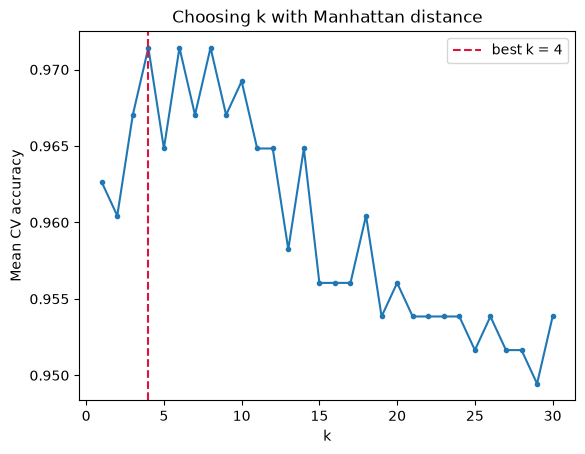

In [8]:
# The cross-validation curve shows how accuracy changes as k changes.

plt.plot(list(k_values),cv_scores_manhattan,marker="o",markersize=3)

plt.axvline(best_k_manhattan,color="crimson",linestyle="--",label=f"best k = {best_k_manhattan}")

plt.xlabel("k")
plt.ylabel("Mean CV accuracy")
plt.title("Choosing k with Manhattan distance")
plt.legend()
plt.show()

Cell 9 

In [9]:
# Compare the best k and the mean cross-validation accuracy for Euclidean and Manhattan distance.

print("Euclidean:")
print("Best k:", 8)
print("Mean CV accuracy:", 0.9714)

print("-" * 30)

print("Manhattan:")
print("Best k:", best_k_manhattan)
print(
    "Mean CV accuracy:",
    round(max(cv_scores_manhattan), 4)
)

Euclidean:
Best k: 8
Mean CV accuracy: 0.9714
------------------------------
Manhattan:
Best k: 4
Mean CV accuracy: 0.9714


Cell 10

In [10]:
# The exercise asks whether changing the distance metric changes the best k or the best cross-validation accuracy.

print("Did the best k change?")

if best_k_manhattan == 8:
    print("No")
else:
    print("Yes")

print("-" * 30)

print("Did the best CV accuracy change?")

if round(max(cv_scores_manhattan), 4) == 0.9714:
    print("No")
else:
    print("Yes")

Did the best k change?
Yes
------------------------------
Did the best CV accuracy change?
No
